Image loaded successfully
Image shape: (1920, 1080, 3)
Image size: 1080 x 1920


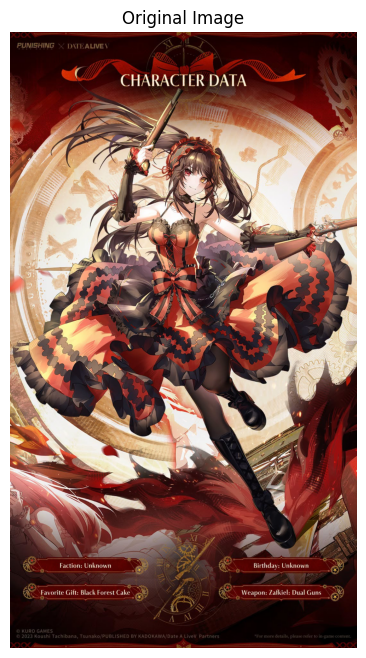

In [ ]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IMAGE_PATH = "/content/img.jpg"
BLOCK_SIZES = [(4, 4), (8, 8), (16, 16), (32, 32), (64, 64)]
OUTPUT_DIR = "/content/labwork7_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise ValueError("Could not load image.")

print("Image loaded successfully")
print("Image shape:", image.shape)
print("Image size:", image.shape[1], "x", image.shape[0])

plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

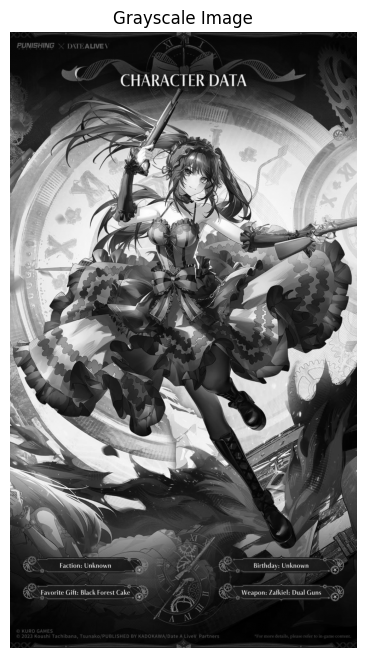

In [ ]:
def grayscale_map(image, block_size=(16, 16)):
    height, width = image.shape[:2]
    output = np.empty((height, width), dtype=np.uint8)

    block_h, block_w = block_size

    for y in range(0, height, block_h):
        for x in range(0, width, block_w):
            y_end = min(y + block_h, height)
            x_end = min(x + block_w, width)

            block = image[y:y_end, x:x_end]

            b = block[:, :, 0].astype(np.float32)
            g = block[:, :, 1].astype(np.float32)
            r = block[:, :, 2].astype(np.float32)

            gray_block = (0.114 * b + 0.587 * g + 0.299 * r)
            output[y:y_end, x:x_end] = gray_block.astype(np.uint8)

    return output

gray_image = grayscale_map(image, (16, 16))

plt.figure(figsize=(6, 8))
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Minimum intensity: 0
Maximum intensity: 255


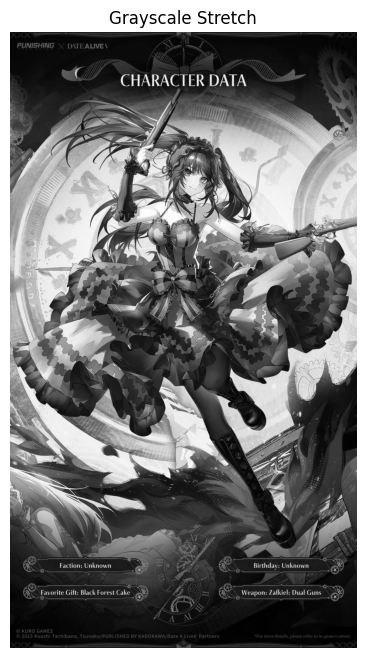

In [ ]:
def reduce_min_max(gray_image, block_size=(16, 16)):
    height, width = gray_image.shape
    block_h, block_w = block_size

    block_mins = []
    block_maxs = []

    for y in range(0, height, block_h):
        for x in range(0, width, block_w):

            y_end = min(y + block_h, height)
            x_end = min(x + block_w, width)

            block = gray_image[y:y_end, x:x_end]

            block_mins.append(np.min(block))
            block_maxs.append(np.max(block))

    global_min = np.min(block_mins)
    global_max = np.max(block_maxs)

    return int(global_min), int(global_max)

def stretch_map(gray_image, min_value, max_value, block_size=(16, 16)):
    height, width = gray_image.shape
    output = np.empty_like(gray_image)
    block_h, block_w = block_size

    if max_value == min_value:
        return np.zeros_like(gray_image)

    for y in range(0, height, block_h):
        for x in range(0, width, block_w):
            y_end = min(y + block_h, height)
            x_end = min(x + block_w, width)

            block = gray_image[y:y_end, x:x_end].astype(np.float32)

            stretched = ((block - min_value) / (max_value - min_value) * 255.0)

            output[y:y_end, x:x_end] = np.clip(stretched, 0, 255).astype(np.uint8)

    return output

def grayscale_stretch(image, block_size=(16, 16)):
    gray = grayscale_map(image, block_size)
    min_value, max_value = reduce_min_max(gray, block_size)
    stretched = stretch_map(gray, min_value, max_value, block_size)

    return gray, stretched, min_value, max_value

gray_image, stretched_image, min_value, max_value = (grayscale_stretch(image, (16, 16)))

print("Minimum intensity:", min_value)
print("Maximum intensity:", max_value)

plt.figure(figsize=(6, 8))
plt.imshow(stretched_image, cmap="gray")
plt.title("Grayscale Stretch")
plt.axis("off")
plt.show()

In [ ]:
benchmark_results = []
stretch_results = {}

for block_size in BLOCK_SIZES:
    print(f"Testing block size: {block_size[0]} x {block_size[1]}")

    start = time.perf_counter()
    gray, stretched, min_val, max_val = grayscale_stretch(image, block_size)
    elapsed = time.perf_counter() - start

    benchmark_results.append({
        "Block Size": f"{block_size[0]} x {block_size[1]}",
        "Execution Time (s)": elapsed,
        "Min Intensity": min_val,
        "Max Intensity": max_val
    })

    stretch_results[block_size] = stretched

benchmark_df = pd.DataFrame(benchmark_results)

print("\nBenchmark Results:")
display(benchmark_df)

Testing block size: 4 x 4
Testing block size: 8 x 8
Testing block size: 16 x 16
Testing block size: 32 x 32
Testing block size: 64 x 64

Benchmark Results:


,Block Size,Execution Time (s),Min Intensity,Max Intensity
0,4 x 4,3.686888,0,255
1,8 x 8,1.200321,0,255
2,16 x 16,0.226212,0,255
3,32 x 32,0.077870,0,255
4,64 x 64,0.028527,0,255


Correctness check:
4 x 4 -> identical to 16 x 16: True
8 x 8 -> identical to 16 x 16: True
16 x 16 -> identical to 16 x 16: True
32 x 32 -> identical to 16 x 16: True
64 x 64 -> identical to 16 x 16: True


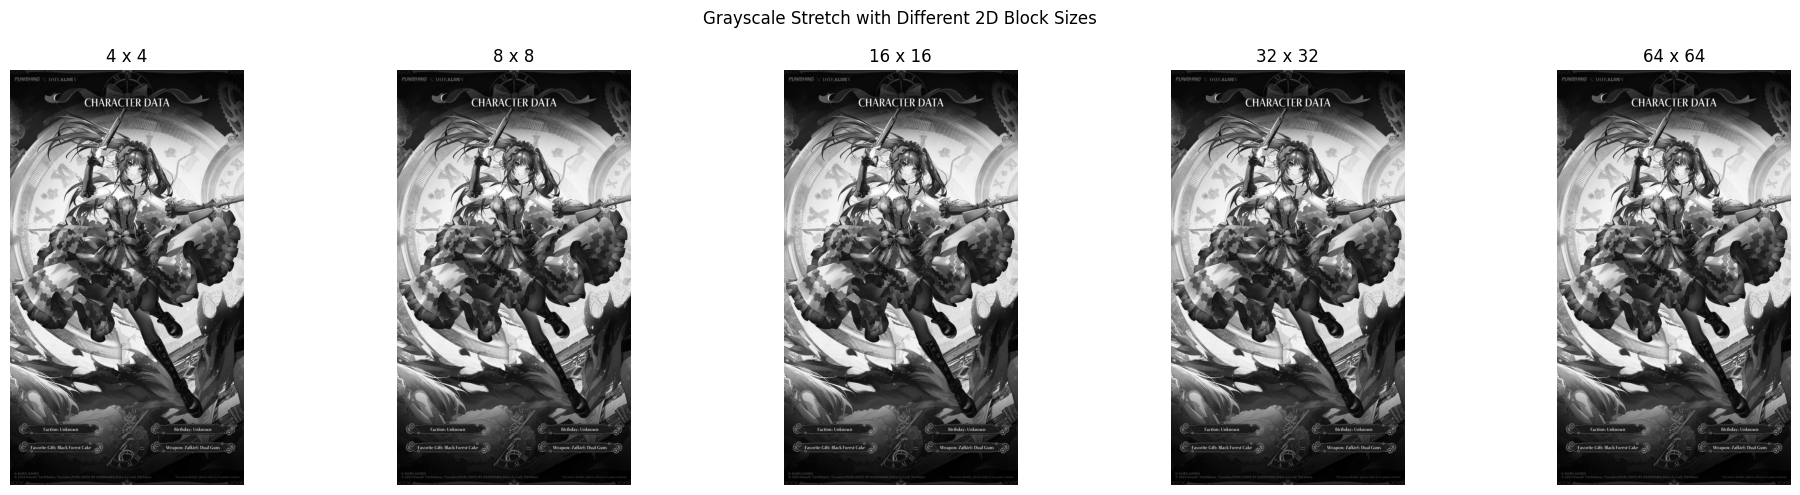

In [ ]:
reference = stretch_results[(16, 16)]

print("Correctness check:")

for block_size, result in stretch_results.items():
    identical = np.array_equal(reference, result)

    print(
        f"{block_size[0]} x {block_size[1]} "
        f"-> identical to 16 x 16: {identical}"
    )

fig, axes = plt.subplots(1, len(BLOCK_SIZES), figsize=(20, 5))

for ax, block_size in zip(axes, BLOCK_SIZES):
    ax.imshow(stretch_results[block_size], cmap="gray")
    ax.set_title(f"{block_size[0]} x {block_size[1]}")
    ax.axis("off")

plt.suptitle("Grayscale Stretch with Different 2D Block Sizes")
plt.tight_layout()
plt.show()